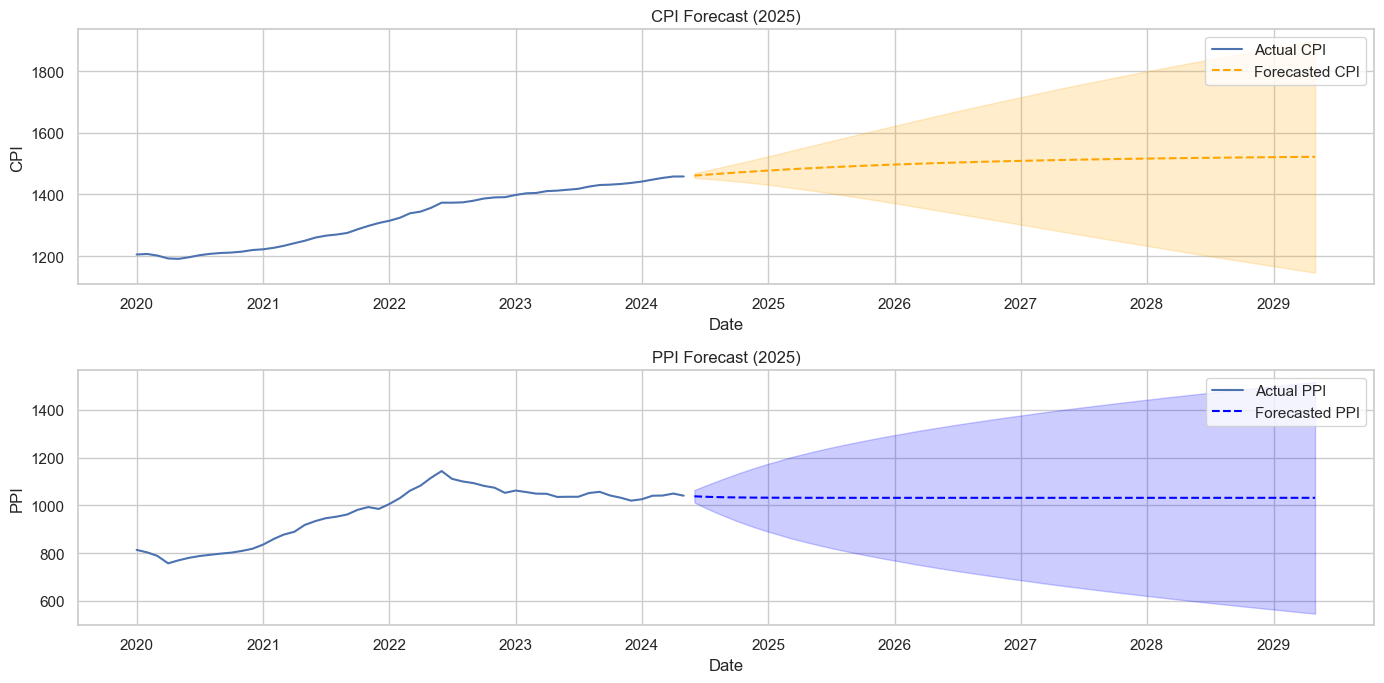

In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Example of creating a DateTime index with frequency
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start

# rename the columns of the dataframe
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)

df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)

# get data from 2020 to 2024-05-01
df_mod = df_mod.loc['2020-01-01':'2024-05-01']

# Ensure that 'CPI' and 'PPI' columns are numeric
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)

# Set frequency of the DateTime index
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Determine the best ARIMA model for CPI (example order used here)
best_cfg_cpi = (1, 1, 1)  # Example order

# Fit ARIMA model for CPI
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()

# Forecast the next 12 months for CPI
forecast_cpi = arima_result_cpi.get_forecast(steps=60)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

# Determine the best ARIMA model for PPI (example order used here)
best_cfg_ppi = (1, 1, 1)  # Example order

# Fit ARIMA model for PPI
arima_model_ppi = ARIMA(df_mod['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()

# Forecast the next 60 months for PPI
forecast_ppi = arima_result_ppi.get_forecast(steps=60)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Plot the forecasts
plt.figure(figsize=(14, 7))

# CPI Forecast
plt.subplot(2, 1, 1)
plt.plot(df_mod['CPI'], label='Actual CPI')
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='--', color='orange')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(2, 1, 2)
plt.plot(df_mod['PPI'], label='Actual PPI')
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='--', color='blue')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)

plt.tight_layout()
plt.show()


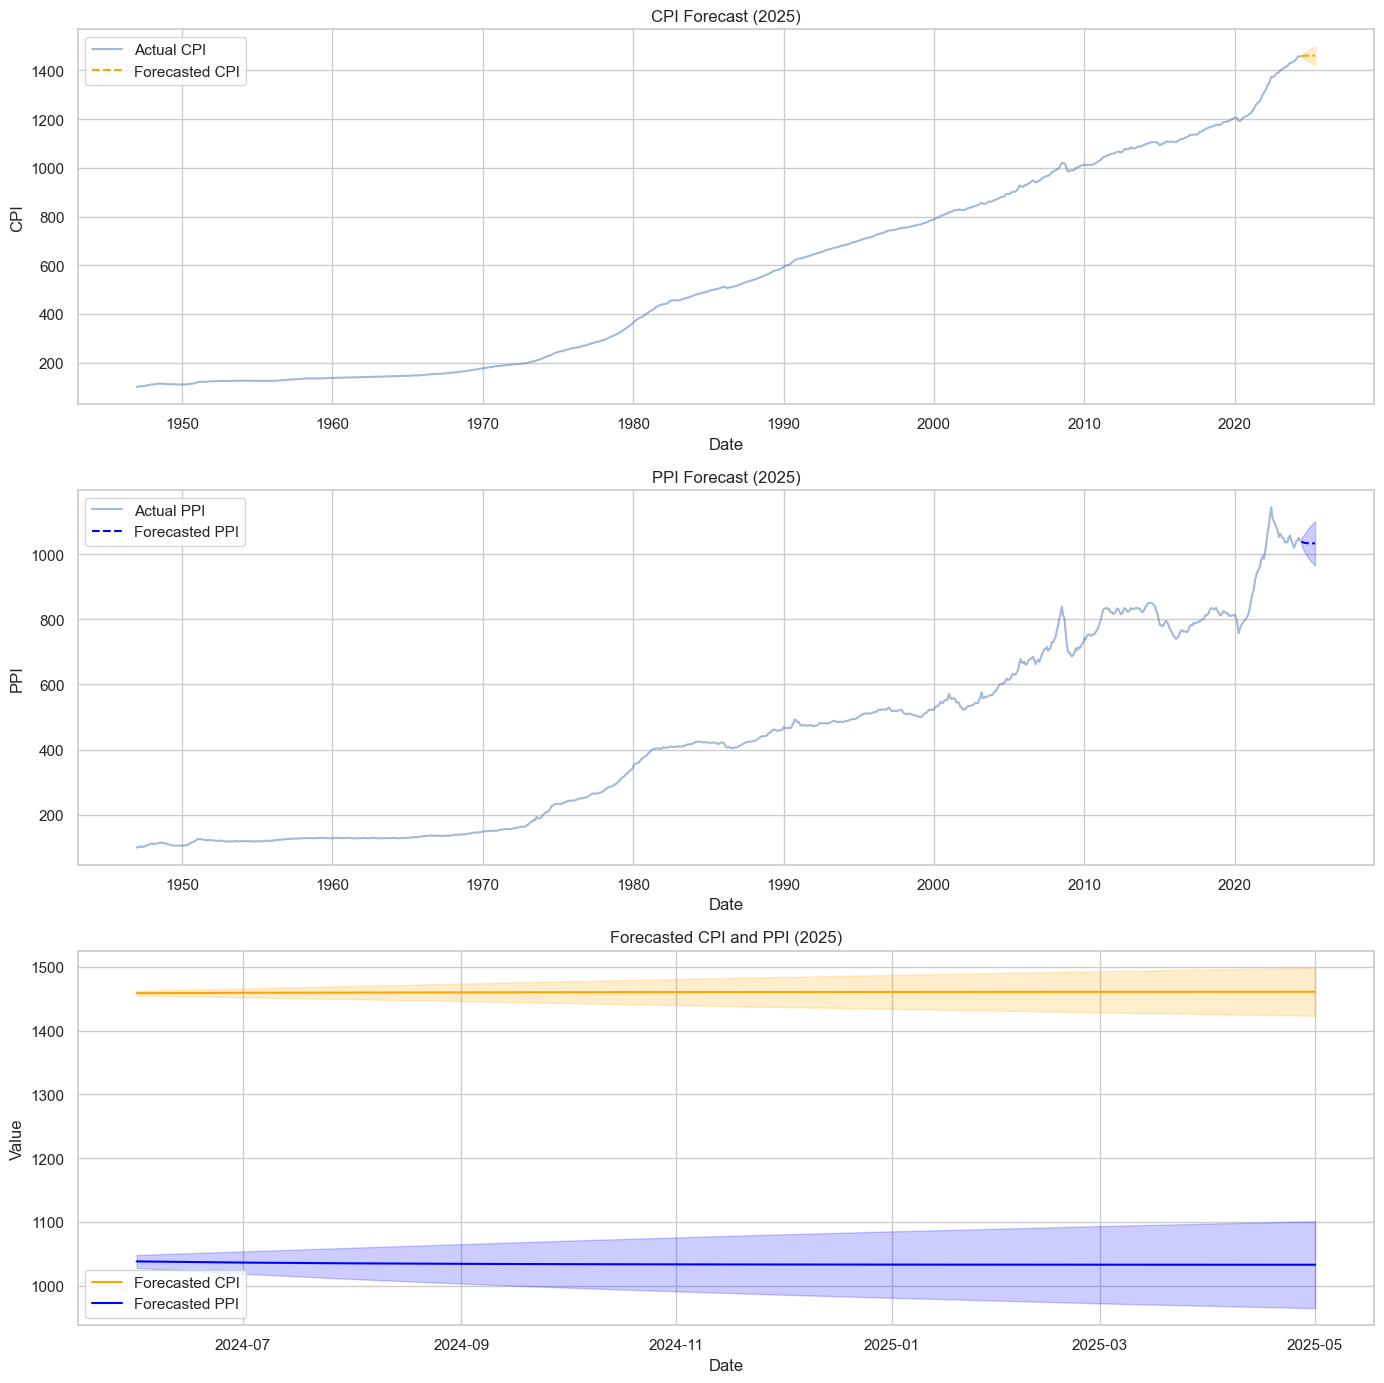

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Load the data
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Rename the columns of the dataframe
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)

df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)

# Ensure that 'CPI' and 'PPI' columns are numeric
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)

# Set frequency of the DateTime index
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Determine the best ARIMA model for CPI (example order used here)
best_cfg_cpi = (1, 1, 1)  # Example order

# Fit ARIMA model for CPI
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()

# Forecast the next 12 months for CPI
forecast_cpi = arima_result_cpi.get_forecast(steps=12)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

# Determine the best ARIMA model for PPI (example order used here)
best_cfg_ppi = (1, 1, 1)  # Example order

# Fit ARIMA model for PPI
arima_model_ppi = ARIMA(df_mod['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()

# Forecast the next 12 months for PPI
forecast_ppi = arima_result_ppi.get_forecast(steps=12)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Plot the forecasts
plt.figure(figsize=(14, 14))

# CPI Forecast
plt.subplot(3, 1, 1)
plt.plot(df_mod['CPI'], label='Actual CPI', alpha=0.5)
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='--', color='orange')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(3, 1, 2)
plt.plot(df_mod['PPI'], label='Actual PPI', alpha=0.5)
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='--', color='blue')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)

# CPI and PPI Forecasted Results Only
plt.subplot(3, 1, 3)
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', color='orange')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', color='blue')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('Forecasted CPI and PPI (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)

plt.tight_layout()
plt.show()


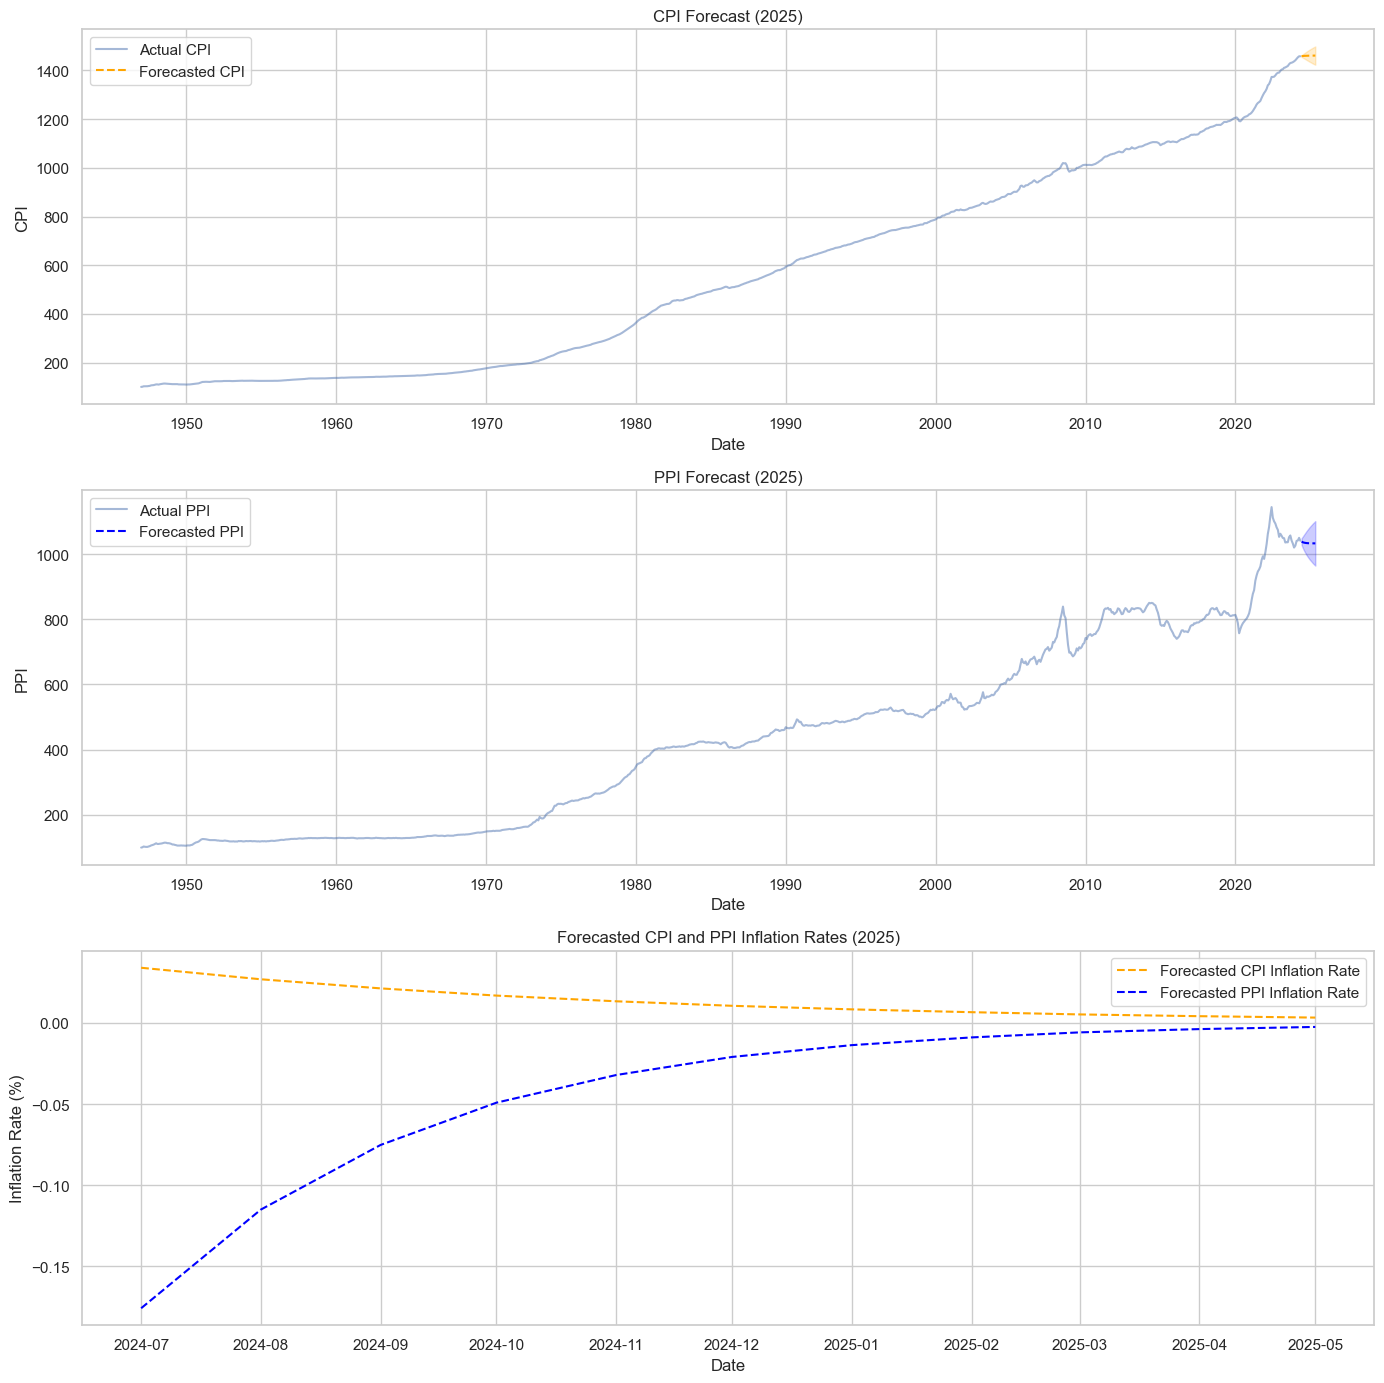

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Load the data
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Rename the columns of the dataframe
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)

df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)

# Ensure that 'CPI' and 'PPI' columns are numeric
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)

# Set frequency of the DateTime index
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Determine the best ARIMA model for CPI (example order used here)
best_cfg_cpi = (1, 1, 1)  # Example order

# Fit ARIMA model for CPI
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()

# Forecast the next 12 months for CPI
forecast_cpi = arima_result_cpi.get_forecast(steps=12)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

# Determine the best ARIMA model for PPI (example order used here)
best_cfg_ppi = (1, 1, 1)  # Example order

# Fit ARIMA model for PPI
arima_model_ppi = ARIMA(df_mod['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()

# Forecast the next 12 months for PPI
forecast_ppi = arima_result_ppi.get_forecast(steps=12)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Calculate the inflation rates
df_mod['CPI_inflation_rate'] = df_mod['CPI'].pct_change() * 100
df_mod['PPI_inflation_rate'] = df_mod['PPI'].pct_change() * 100

# Forecast the inflation rates for the next 12 months
cpi_inflation_forecast = forecast_cpi_df['Forecast'].pct_change() * 100
ppi_inflation_forecast = forecast_ppi_df['Forecast'].pct_change() * 100

# Create a DataFrame for the forecasted inflation rates
forecast_inflation_df = pd.DataFrame({
    'CPI_Forecasted_Inflation': cpi_inflation_forecast,
    'PPI_Forecasted_Inflation': ppi_inflation_forecast
}, index=forecast_cpi_df.index[1:])  # Align with the forecast dates

# Plot the results
plt.figure(figsize=(14, 14))

# CPI Forecast
plt.subplot(3, 1, 1)
plt.plot(df_mod['CPI'], label='Actual CPI', alpha=0.5)
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='--', color='orange')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(3, 1, 2)
plt.plot(df_mod['PPI'], label='Actual PPI', alpha=0.5)
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='--', color='blue')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)

# CPI and PPI Forecasted Inflation Rates
plt.subplot(3, 1, 3)
plt.plot(forecast_inflation_df.index, forecast_inflation_df['CPI_Forecasted_Inflation'], label='Forecasted CPI Inflation Rate', linestyle='--', color='orange')
plt.plot(forecast_inflation_df.index, forecast_inflation_df['PPI_Forecasted_Inflation'], label='Forecasted PPI Inflation Rate', linestyle='--', color='blue')
plt.title('Forecasted CPI and PPI Inflation Rates (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)

plt.tight_layout()
plt.show()


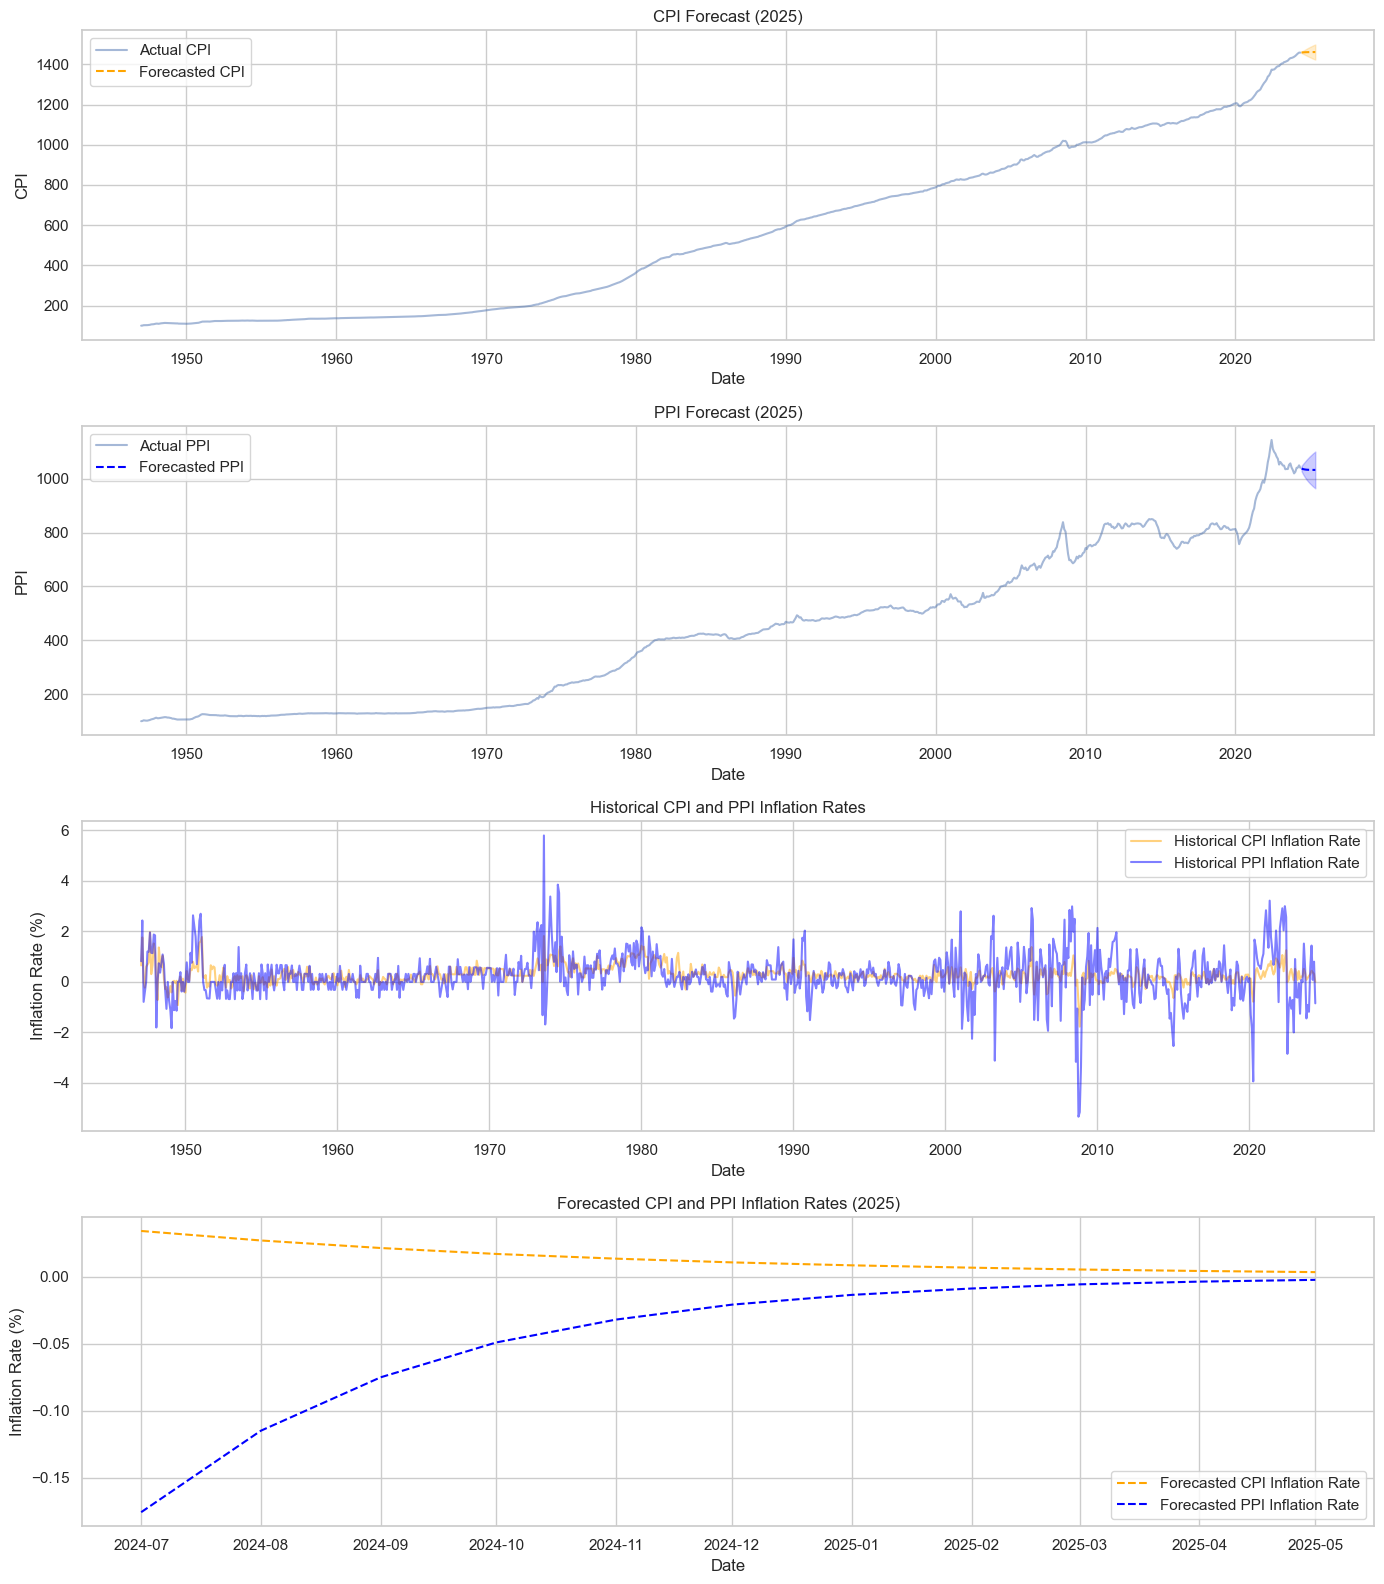

In [85]:
# Plot the results
plt.figure(figsize=(14, 16))

# CPI Forecast
plt.subplot(4, 1, 1)
plt.plot(df_mod['CPI'], label='Actual CPI', alpha=0.5)
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='--', color='orange')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(4, 1, 2)
plt.plot(df_mod['PPI'], label='Actual PPI', alpha=0.5)
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='--', color='blue')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)

# Historical CPI and PPI Inflation Rates
plt.subplot(4, 1, 3)
plt.plot(df_mod.index, df_mod['CPI_inflation_rate'], label='Historical CPI Inflation Rate', alpha=0.5, color='orange')
plt.plot(df_mod.index, df_mod['PPI_inflation_rate'], label='Historical PPI Inflation Rate', alpha=0.5, color='blue')
plt.title('Historical CPI and PPI Inflation Rates')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)

# CPI and PPI Forecasted Inflation Rates
plt.subplot(4, 1, 4)
plt.plot(forecast_inflation_df.index, forecast_inflation_df['CPI_Forecasted_Inflation'], label='Forecasted CPI Inflation Rate', linestyle='--', color='orange')
plt.plot(forecast_inflation_df.index, forecast_inflation_df['PPI_Forecasted_Inflation'], label='Forecasted PPI Inflation Rate', linestyle='--', color='blue')
plt.title('Forecasted CPI and PPI Inflation Rates (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)

plt.tight_layout()
plt.show()


In [86]:
# Example of different ARIMA configurations
orders = [(0, 1, 0), (1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 1, 2)]  # Example configurations

for order in orders:
    model_cpi = ARIMA(df_mod['CPI'], order=order)
    result_cpi = model_cpi.fit()
    print(f"Order {order}: AIC = {result_cpi.aic}")

# Choose the order with the lowest AIC and refit the model
best_order_cpi = (1, 1, 1)  # Replace with the best order based on AIC
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_order_cpi)
arima_result_cpi = arima_model_cpi.fit()


Order (0, 1, 0): AIC = 4440.942317945139
Order (1, 1, 0): AIC = 3772.847900252641
Order (0, 1, 1): AIC = 3970.232982314102
Order (1, 1, 1): AIC = 3772.306232413099
Order (2, 1, 2): AIC = 3638.2436299812603


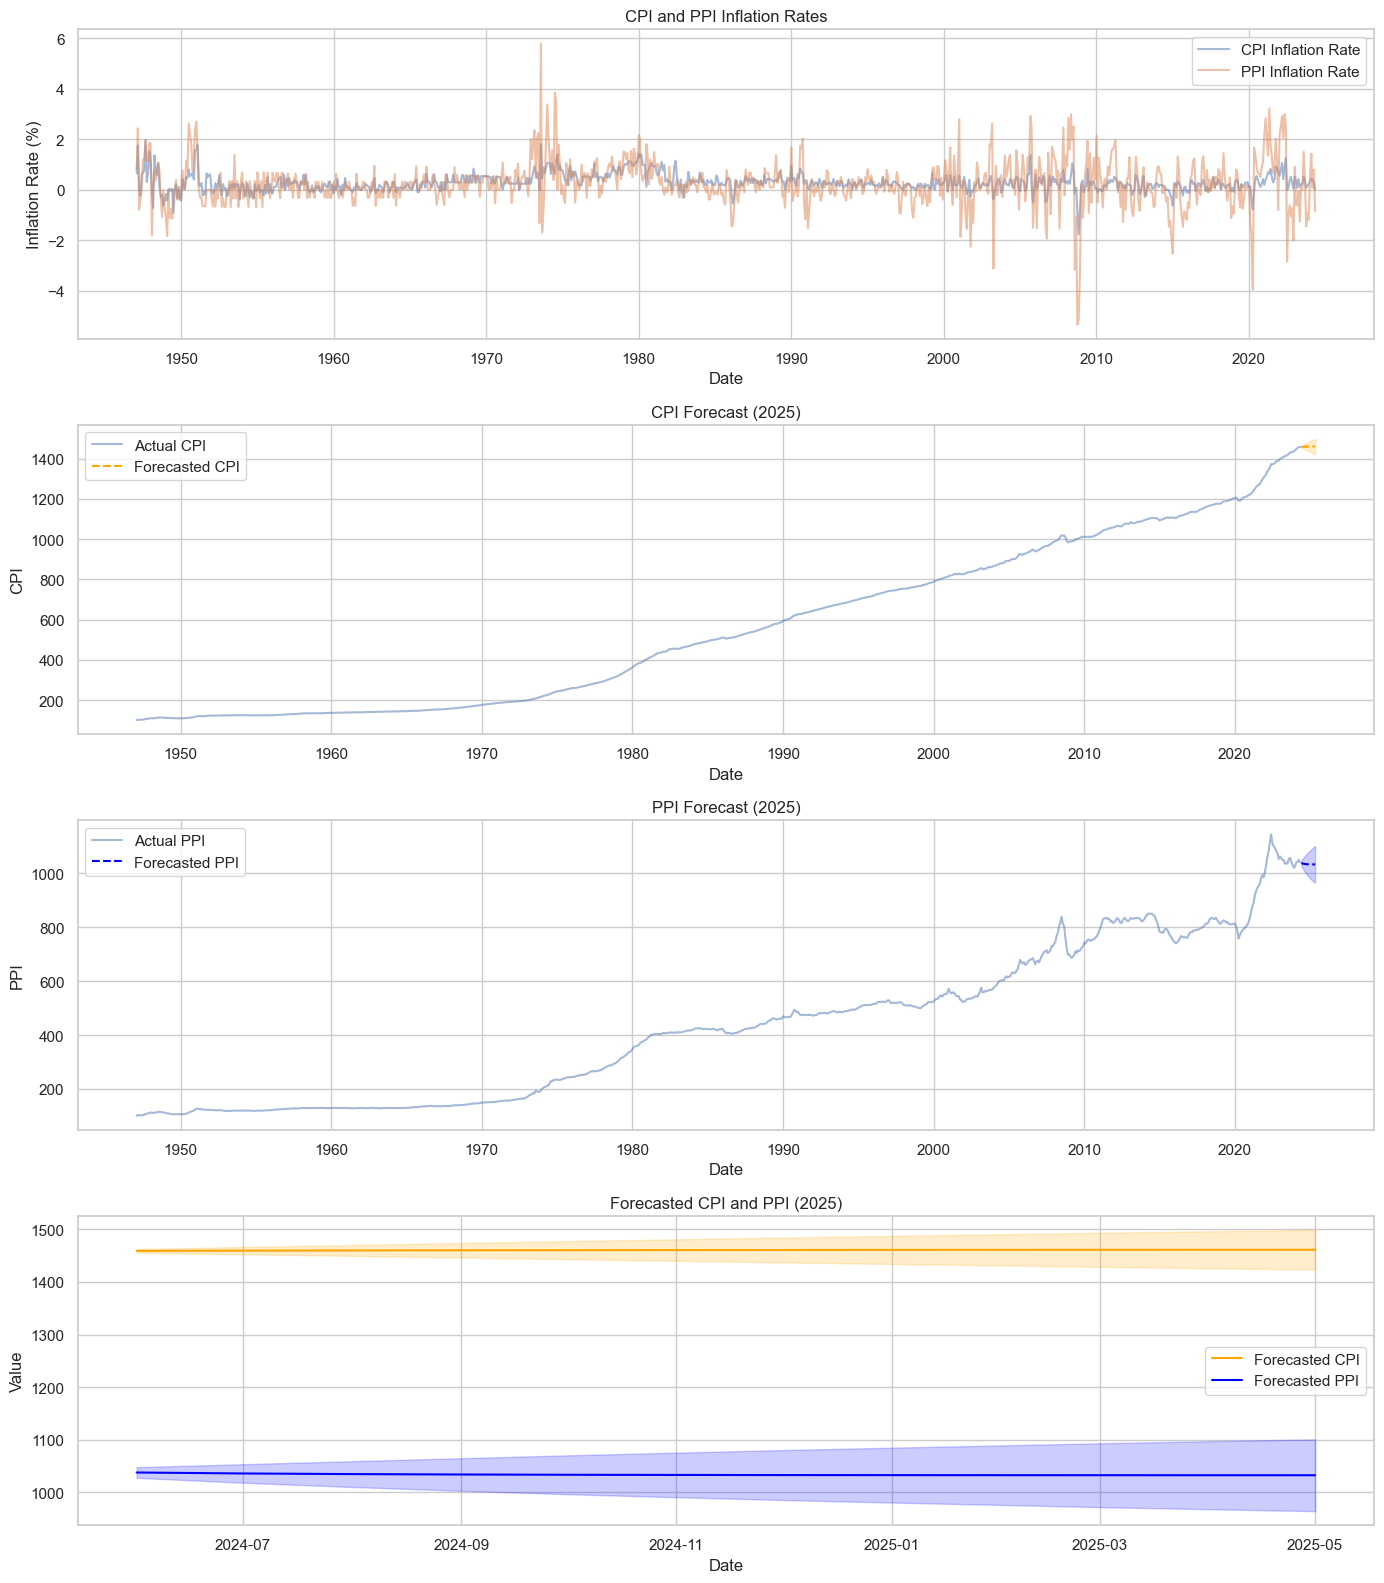

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Load the data
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Rename the columns of the dataframe
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)

df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)

# Ensure that 'CPI' and 'PPI' columns are numeric
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)

# Set frequency of the DateTime index
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Calculate the inflation rates
df_mod['CPI_inflation'] = df_mod['CPI'].pct_change() * 100
df_mod['PPI_inflation'] = df_mod['PPI'].pct_change() * 100

# Drop the first row with NaN values due to pct_change()
df_mod.dropna(inplace=True)

# Determine the best ARIMA model for CPI (example order used here)
best_cfg_cpi = (1, 1, 1)  # Example order

# Fit ARIMA model for CPI
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()

# Forecast the next 12 months for CPI
forecast_cpi = arima_result_cpi.get_forecast(steps=12)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

# Determine the best ARIMA model for PPI (example order used here)
best_cfg_ppi = (1, 1, 1)  # Example order

# Fit ARIMA model for PPI
arima_model_ppi = ARIMA(df_mod['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()

# Forecast the next 12 months for PPI
forecast_ppi = arima_result_ppi.get_forecast(steps=12)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Calculate the forecasted inflation rates
forecast_cpi_df['Forecast_inflation'] = forecast_cpi_df['Forecast'].pct_change() * 100
forecast_ppi_df['Forecast_inflation'] = forecast_ppi_df['Forecast'].pct_change() * 100

# Plot the forecasts and inflation rates
plt.figure(figsize=(14, 16))

# CPI and PPI Inflation Rates
plt.subplot(4, 1, 1)
plt.plot(df_mod['CPI_inflation'], label='CPI Inflation Rate', alpha=0.5)
plt.plot(df_mod['PPI_inflation'], label='PPI Inflation Rate', alpha=0.5)
plt.title('CPI and PPI Inflation Rates')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)

# CPI Forecast
plt.subplot(4, 1, 2)
plt.plot(df_mod['CPI'], label='Actual CPI', alpha=0.5)
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='--', color='orange')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(4, 1, 3)
plt.plot(df_mod['PPI'], label='Actual PPI', alpha=0.5)
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='--', color='blue')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)

# CPI and PPI Forecasted Results Only
plt.subplot(4, 1, 4)
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', color='orange')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', color='blue')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('Forecasted CPI and PPI (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)

plt.tight_layout()
plt.show()


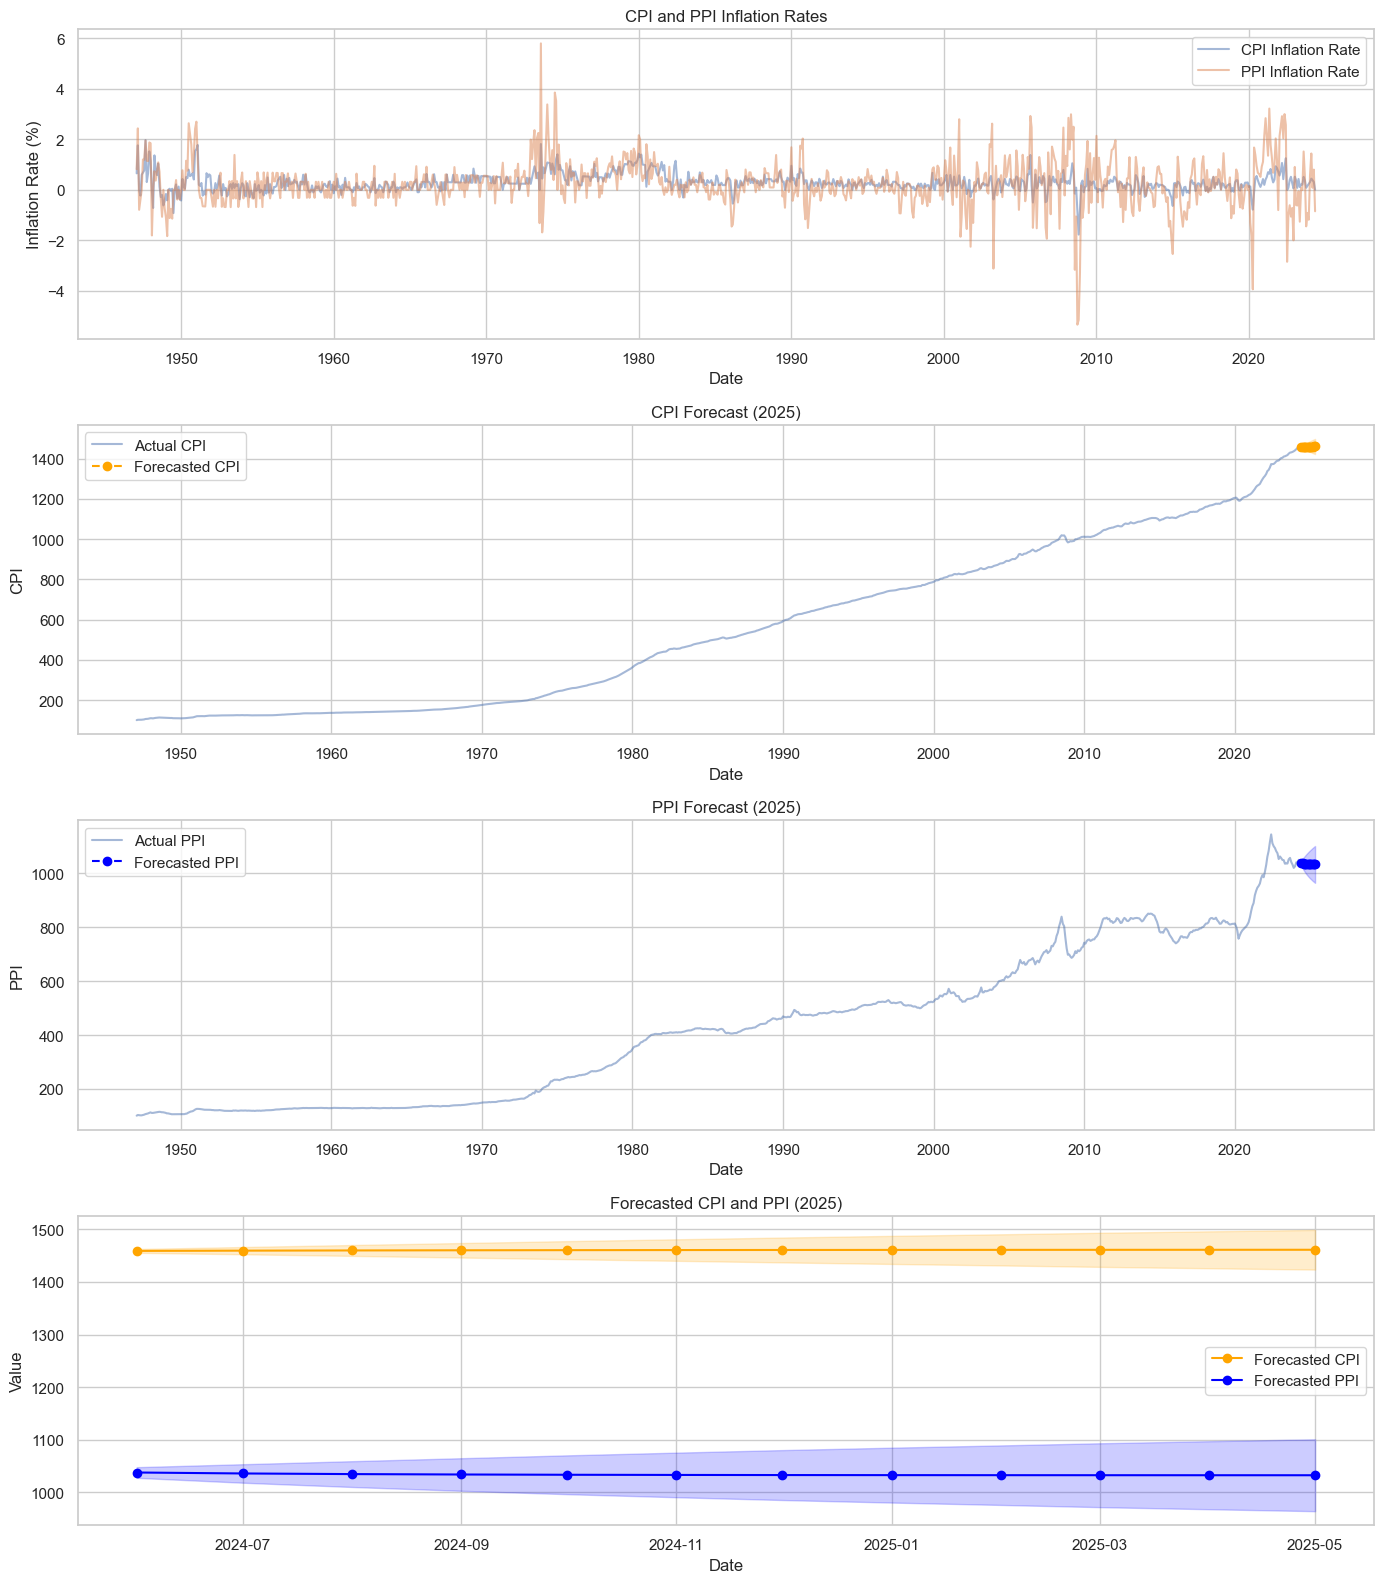

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Load the data
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Rename the columns of the dataframe
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)

df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)

# Ensure that 'CPI' and 'PPI' columns are numeric
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)

# Set frequency of the DateTime index
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Calculate the inflation rates
df_mod['CPI_inflation'] = df_mod['CPI'].pct_change() * 100
df_mod['PPI_inflation'] = df_mod['PPI'].pct_change() * 100

# Drop the first row with NaN values due to pct_change()
df_mod.dropna(inplace=True)

# Determine the best ARIMA model for CPI (example order used here)
best_cfg_cpi = (1, 1, 1)  # Example order

# Fit ARIMA model for CPI
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()

# Forecast the next 12 months for CPI
forecast_cpi = arima_result_cpi.get_forecast(steps=12)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

# Determine the best ARIMA model for PPI (example order used here)
best_cfg_ppi = (1, 1, 1)  # Example order

# Fit ARIMA model for PPI
arima_model_ppi = ARIMA(df_mod['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()

# Forecast the next 12 months for PPI
forecast_ppi = arima_result_ppi.get_forecast(steps=12)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Calculate the forecasted inflation rates
forecast_cpi_df['Forecast_inflation'] = forecast_cpi_df['Forecast'].pct_change() * 100
forecast_ppi_df['Forecast_inflation'] = forecast_ppi_df['Forecast'].pct_change() * 100

# Plot the forecasts and inflation rates
plt.figure(figsize=(14, 16))

# CPI and PPI Inflation Rates
plt.subplot(4, 1, 1)
plt.plot(df_mod['CPI_inflation'], label='CPI Inflation Rate', alpha=0.5)
plt.plot(df_mod['PPI_inflation'], label='PPI Inflation Rate', alpha=0.5)
plt.title('CPI and PPI Inflation Rates')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)

# CPI Forecast
plt.subplot(4, 1, 2)
plt.plot(df_mod['CPI'], label='Actual CPI', alpha=0.5)
plt.plot(forecast_cpi_df.index, forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='--', color='orange', marker='o')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(4, 1, 3)
plt.plot(df_mod['PPI'], label='Actual PPI', alpha=0.5)
plt.plot(forecast_ppi_df.index, forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='--', color='blue', marker='o')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)

# CPI and PPI Forecasted Results Only
plt.subplot(4, 1, 4)
plt.plot(forecast_cpi_df.index, forecast_cpi_df['Forecast'], label='Forecasted CPI', color='orange', marker='o')
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.plot(forecast_ppi_df.index, forecast_ppi_df['Forecast'], label='Forecasted PPI', color='blue', marker='o')
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('Forecasted CPI and PPI (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)

plt.tight_layout()
plt.show()


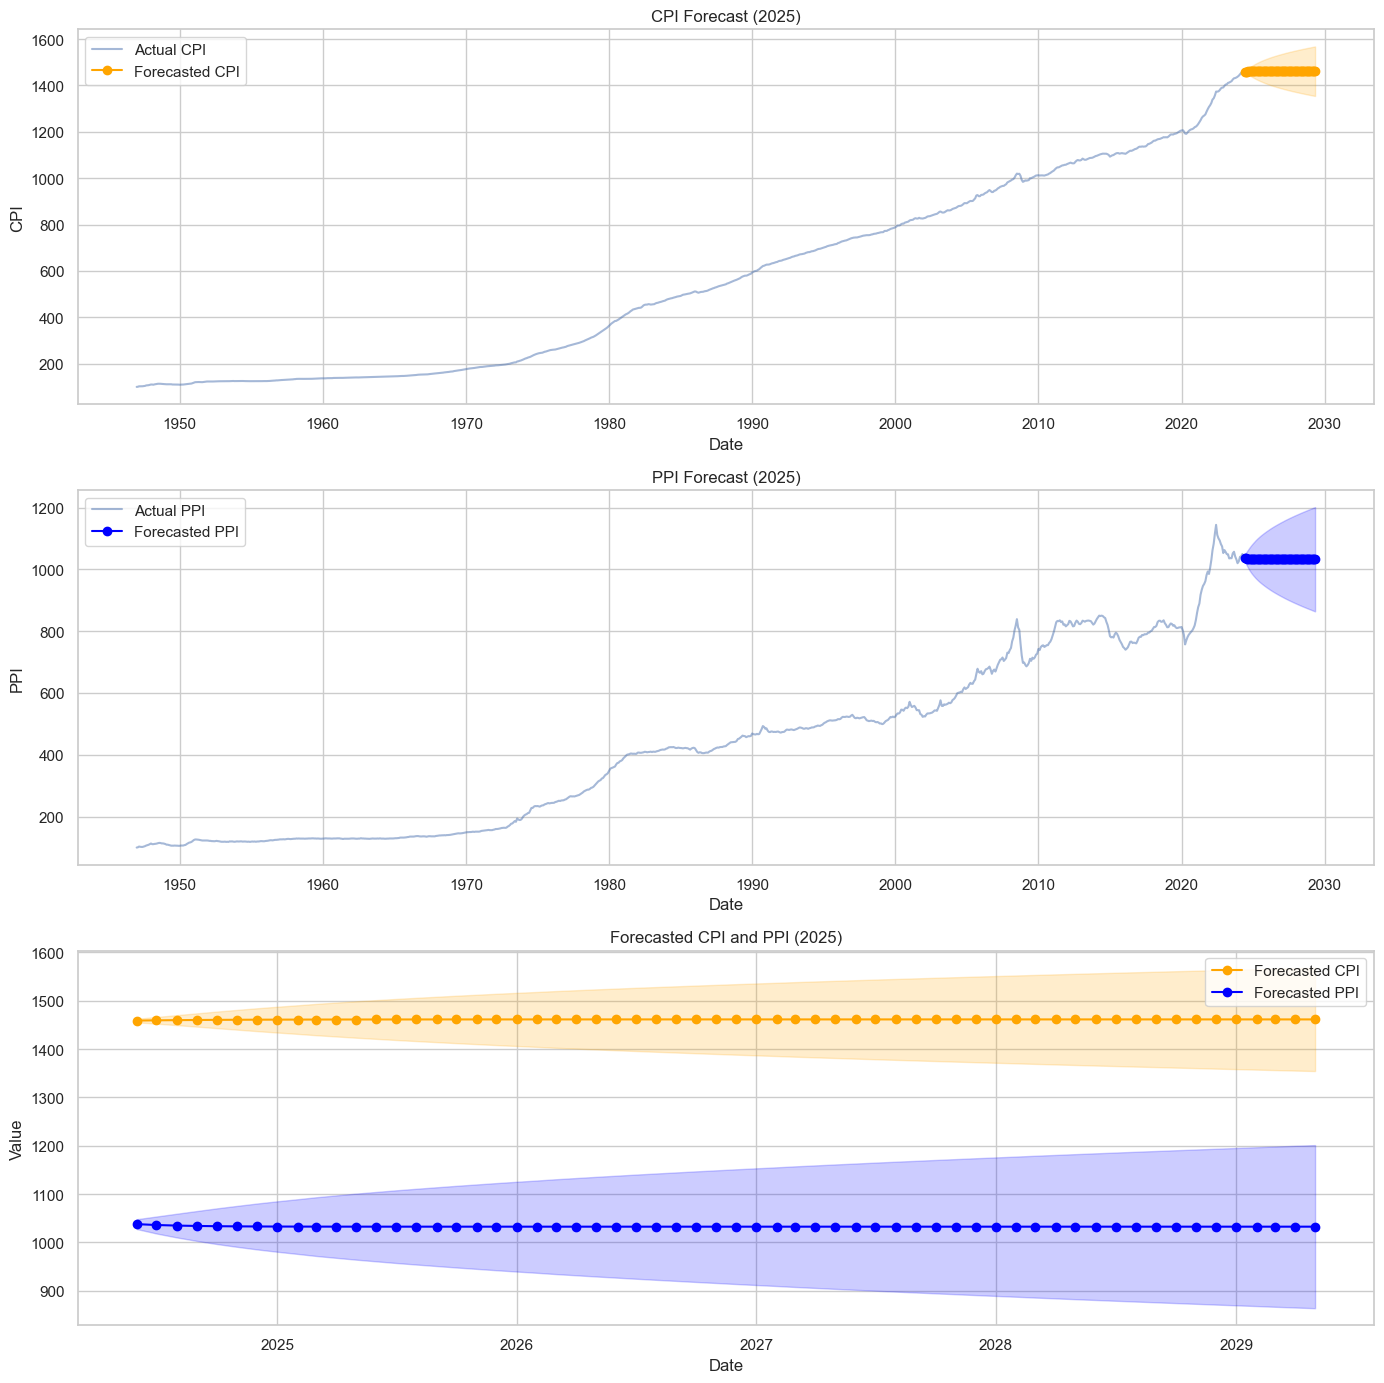

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Load the data
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Rename the columns of the dataframe
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)

df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)

# Ensure that 'CPI' and 'PPI' columns are numeric
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)

# Set frequency of the DateTime index
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Determine the best ARIMA model for CPI (example order used here)
best_cfg_cpi = (1, 1, 1)  # Example order

# Fit ARIMA model for CPI
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()

# Forecast the next 60 months for CPI
forecast_cpi = arima_result_cpi.get_forecast(steps=60)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

# Determine the best ARIMA model for PPI (example order used here)
best_cfg_ppi = (1, 1, 1)  # Example order

# Fit ARIMA model for PPI
arima_model_ppi = ARIMA(df_mod['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()

# Forecast the next 60 months for PPI
forecast_ppi = arima_result_ppi.get_forecast(steps=60)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Plot the forecasts
plt.figure(figsize=(14, 14))

# CPI Forecast
plt.subplot(3, 1, 1)
plt.plot(df_mod['CPI'], label='Actual CPI', alpha=0.5)
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', linestyle='-', color='orange', marker='o')  # Line graph with markers
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(3, 1, 2)
plt.plot(df_mod['PPI'], label='Actual PPI', alpha=0.5)
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', linestyle='-', color='blue', marker='o')  # Line graph with markers
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)

# CPI and PPI Forecasted Results Only
plt.subplot(3, 1, 3)
plt.plot(forecast_cpi_df.index, forecast_cpi_df['Forecast'], label='Forecasted CPI', color='orange', marker='o', linestyle='-')  # Line graph with markers
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.plot(forecast_ppi_df.index, forecast_ppi_df['Forecast'], label='Forecasted PPI', color='blue', marker='o', linestyle='-')  # Line graph with markers
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('Forecasted CPI and PPI (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)

plt.tight_layout()
plt.show()


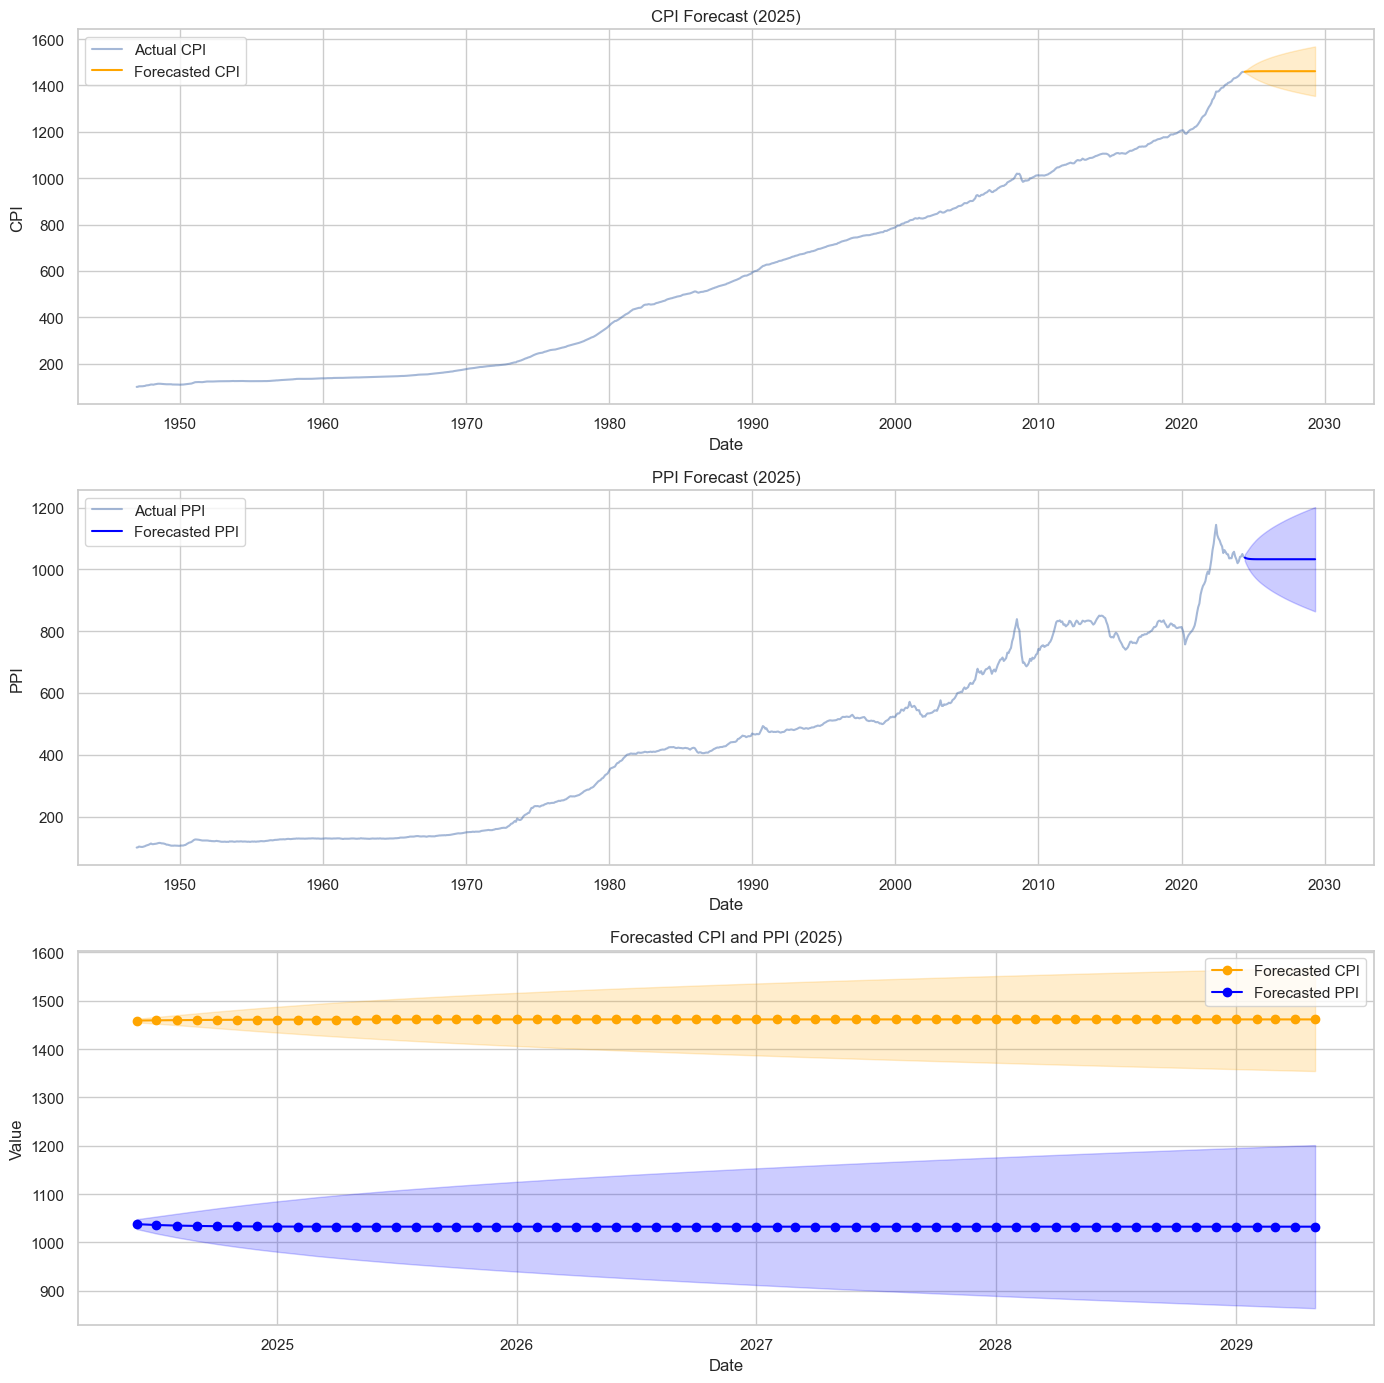

In [90]:
# Plot the forecasts with discrete points
plt.figure(figsize=(14, 14))

# CPI Forecast
plt.subplot(3, 1, 1)
plt.plot(df_mod['CPI'], label='Actual CPI', alpha=0.5)
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', color='orange')  # Line graph with markers
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(3, 1, 2)
plt.plot(df_mod['PPI'], label='Actual PPI', alpha=0.5)
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', color='blue')  # Line graph with markers
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)

# CPI and PPI Forecasted Results Only
plt.subplot(3, 1, 3)
plt.plot(forecast_cpi_df.index, forecast_cpi_df['Forecast'], label='Forecasted CPI', color='orange', marker='o', linestyle='-')  # Line graph with markers
plt.fill_between(forecast_cpi_df.index,
                 forecast_cpi_df.iloc[:, 0],
                 forecast_cpi_df.iloc[:, 1], color='orange', alpha=0.2)
plt.plot(forecast_ppi_df.index, forecast_ppi_df['Forecast'], label='Forecasted PPI', color='blue', marker='o', linestyle='-')  # Line graph with markers
plt.fill_between(forecast_ppi_df.index,
                 forecast_ppi_df.iloc[:, 0],
                 forecast_ppi_df.iloc[:, 1], color='blue', alpha=0.2)
plt.title('Forecasted CPI and PPI (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)

plt.tight_layout()
plt.show()


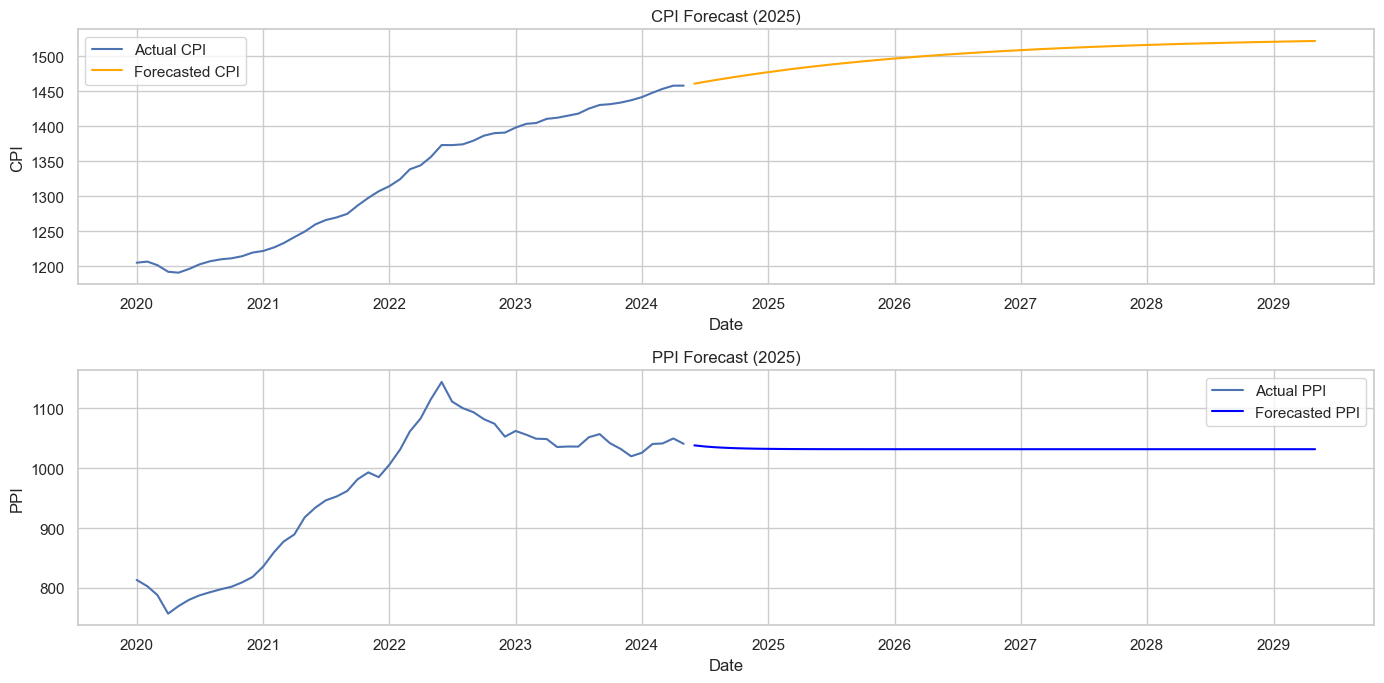

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Load and preprocess the data
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)
df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)
df_mod = df_mod.loc['2020-01-01':'2024-05-01']
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Fit ARIMA models
best_cfg_cpi = (1, 1, 1)
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()
forecast_cpi = arima_result_cpi.get_forecast(steps=60)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

best_cfg_ppi = (1, 1, 1)
arima_model_ppi = ARIMA(df_mod['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()
forecast_ppi = arima_result_ppi.get_forecast(steps=60)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Plot the forecasts without confidence intervals
plt.figure(figsize=(14, 7))

# CPI Forecast
plt.subplot(2, 1, 1)
plt.plot(df_mod['CPI'], label='Actual CPI')
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', color='orange')
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(2, 1, 2)
plt.plot(df_mod['PPI'], label='Actual PPI')
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', color='blue')
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)


plt.tight_layout()
plt.show()


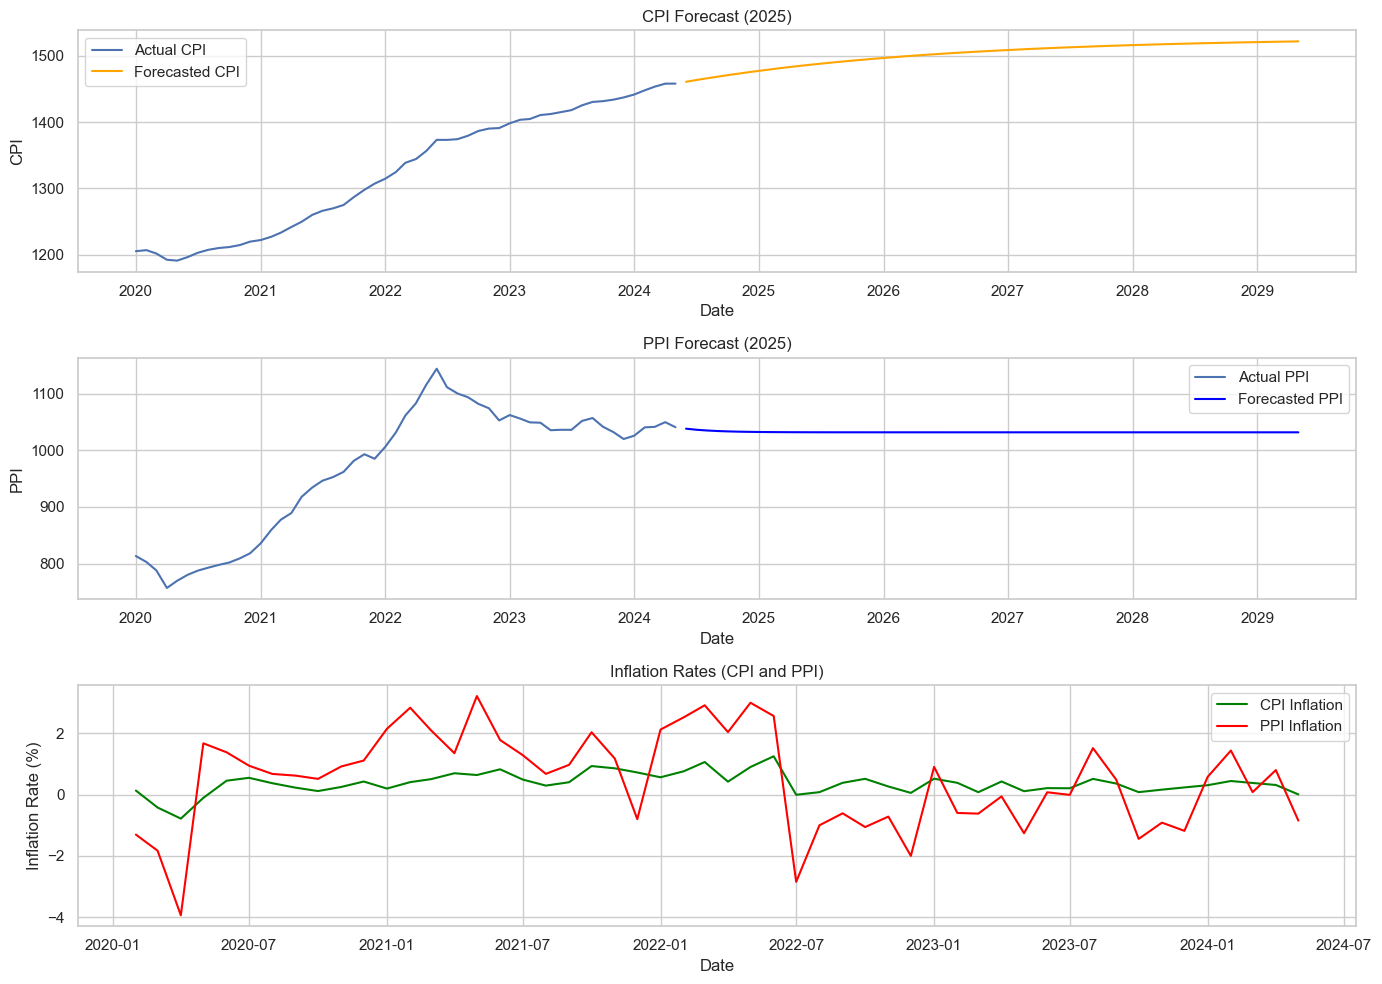

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Load and preprocess the data
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)
df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)
df_mod = df_mod.loc['2020-01-01':'2024-05-01']
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Calculate monthly inflation rates
df_mod['CPI_Inflation'] = df_mod['CPI'].pct_change() * 100
df_mod['PPI_Inflation'] = df_mod['PPI'].pct_change() * 100

# Fit ARIMA models
best_cfg_cpi = (1, 1, 1)
arima_model_cpi = ARIMA(df_mod['CPI'], order=best_cfg_cpi)
arima_result_cpi = arima_model_cpi.fit()
forecast_cpi = arima_result_cpi.get_forecast(steps=60)
forecast_cpi_df = forecast_cpi.conf_int()
forecast_cpi_df['Forecast'] = forecast_cpi.predicted_mean

best_cfg_ppi = (1, 1, 1)
arima_model_ppi = ARIMA(df_mod['PPI'], order=best_cfg_ppi)
arima_result_ppi = arima_model_ppi.fit()
forecast_ppi = arima_result_ppi.get_forecast(steps=60)
forecast_ppi_df = forecast_ppi.conf_int()
forecast_ppi_df['Forecast'] = forecast_ppi.predicted_mean

# Plot the CPI, PPI, and Inflation Rates
plt.figure(figsize=(14, 10))

# CPI Forecast
plt.subplot(3, 1, 1)
plt.plot(df_mod['CPI'], label='Actual CPI')
plt.plot(forecast_cpi_df['Forecast'], label='Forecasted CPI', color='orange')
plt.title('CPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('CPI')
plt.grid(True)

# PPI Forecast
plt.subplot(3, 1, 2)
plt.plot(df_mod['PPI'], label='Actual PPI')
plt.plot(forecast_ppi_df['Forecast'], label='Forecasted PPI', color='blue')
plt.title('PPI Forecast (2025)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('PPI')
plt.grid(True)

# Inflation Rates
plt.subplot(3, 1, 3)
plt.plot(df_mod['CPI_Inflation'], label='CPI Inflation', color='green')
plt.plot(df_mod['PPI_Inflation'], label='PPI Inflation', color='red')
plt.title('Inflation Rates (CPI and PPI)')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)

plt.tight_layout()
plt.show()


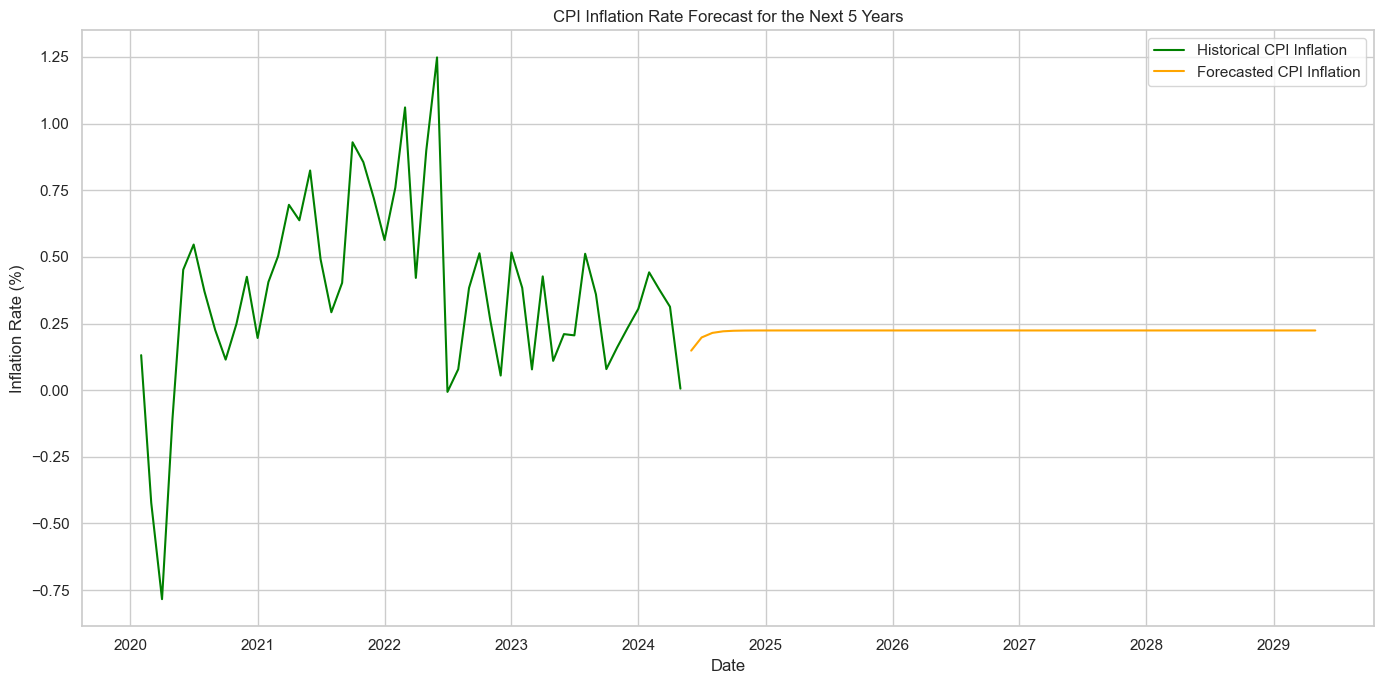

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load and preprocess the data
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)
df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)
df_mod = df_mod.loc['2020-01-01':'2024-05-01']
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Calculate monthly inflation rates
df_mod['CPI_Inflation'] = df_mod['CPI'].pct_change() * 100
df_mod['PPI_Inflation'] = df_mod['PPI'].pct_change() * 100

# Fit ARIMA model on CPI Inflation
best_cfg_cpi_inf = (1, 1, 1)
arima_model_cpi_inf = ARIMA(df_mod['CPI_Inflation'].dropna(), order=best_cfg_cpi_inf)
arima_result_cpi_inf = arima_model_cpi_inf.fit()
forecast_cpi_inf = arima_result_cpi_inf.get_forecast(steps=60)  # 5 years forecast
forecast_cpi_inf_df = forecast_cpi_inf.conf_int()
forecast_cpi_inf_df['Forecast'] = forecast_cpi_inf.predicted_mean

# Plot the inflation rate forecast
plt.figure(figsize=(14, 7))

plt.plot(df_mod['CPI_Inflation'], label='Historical CPI Inflation', color='green')
plt.plot(forecast_cpi_inf_df['Forecast'], label='Forecasted CPI Inflation', color='orange')
plt.title('CPI Inflation Rate Forecast for the Next 5 Years')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)

plt.tight_layout()
plt.show()


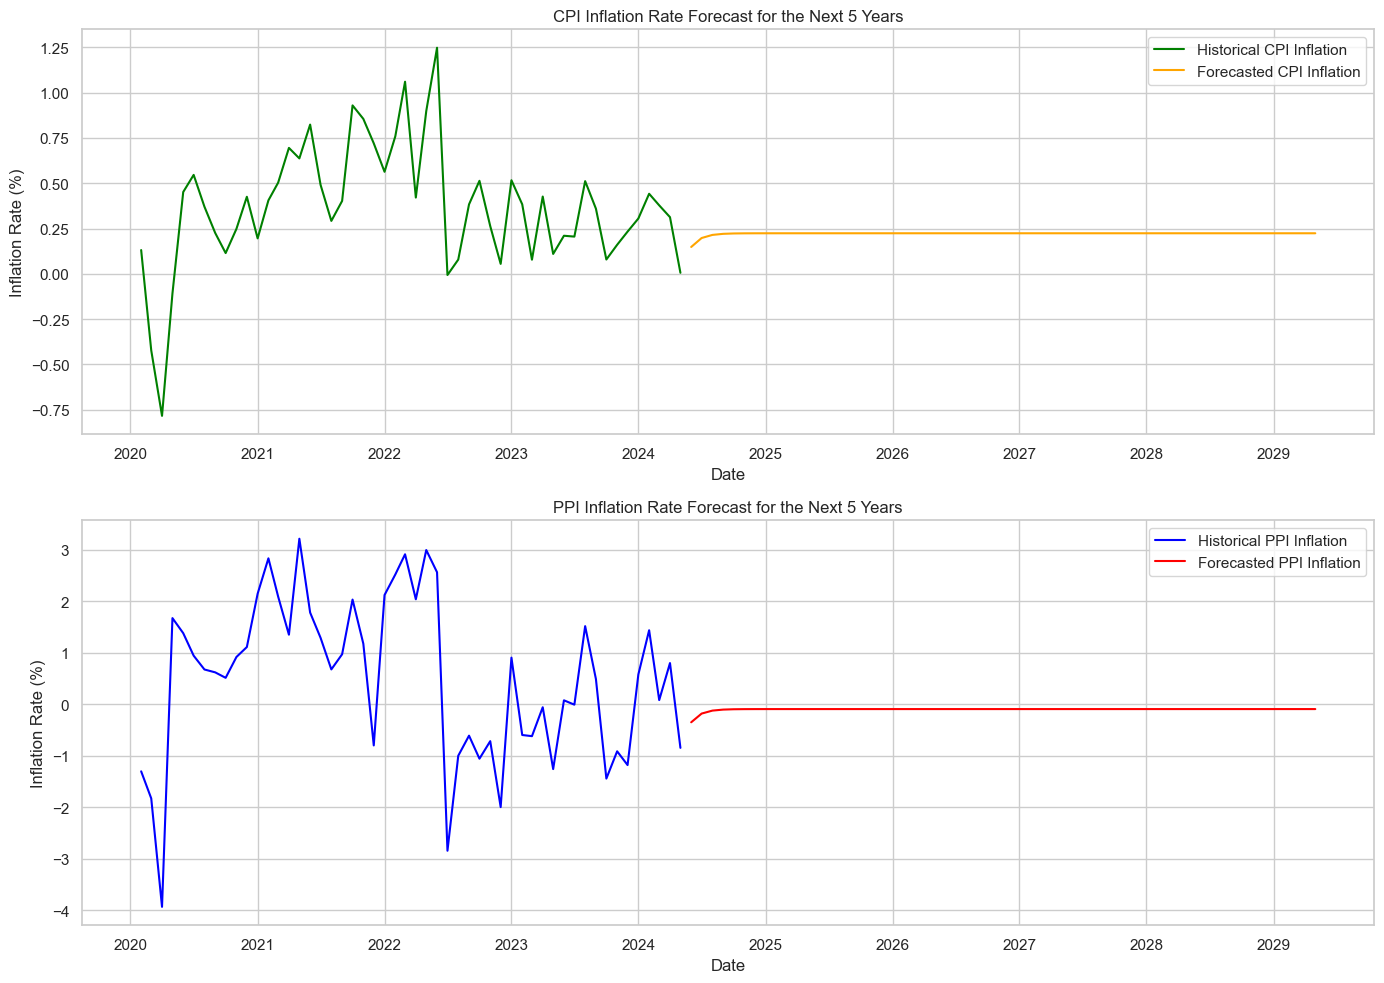

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load and preprocess the data
df_mod = pd.read_csv('./data/CPI_PPI_All_Commodity.csv', index_col='DATE', parse_dates=True)
df_mod.index.freq = 'MS'  # Set frequency to monthly start
df_mod.rename(columns={'DATE': 'Date', 'CPIAUCSL_NBD19470101': 'CPI', 'PPIACO_NBD19470101': 'PPI'}, inplace=True)
df_mod['CPI'] = df_mod['CPI'].replace('.', np.nan)
df_mod.dropna(axis=0, inplace=True)
df_mod = df_mod.loc['2020-01-01':'2024-05-01']
df_mod['CPI'] = df_mod['CPI'].astype(float)
df_mod['PPI'] = df_mod['PPI'].astype(float)
if df_mod.index.freq is None:
    df_mod.index = df_mod.index.to_period('M').to_timestamp()  # Convert to Timestamp
    df_mod.index.freq = 'MS'  # Set frequency to monthly start

# Calculate monthly inflation rates
df_mod['CPI_Inflation'] = df_mod['CPI'].pct_change() * 100
df_mod['PPI_Inflation'] = df_mod['PPI'].pct_change() * 100

# Fit ARIMA model on CPI Inflation
best_cfg_cpi_inf = (1, 1, 1)
arima_model_cpi_inf = ARIMA(df_mod['CPI_Inflation'].dropna(), order=best_cfg_cpi_inf)
arima_result_cpi_inf = arima_model_cpi_inf.fit()
forecast_cpi_inf = arima_result_cpi_inf.get_forecast(steps=60)  # 5 years forecast
forecast_cpi_inf_df = forecast_cpi_inf.conf_int()
forecast_cpi_inf_df['Forecast'] = forecast_cpi_inf.predicted_mean

# Fit ARIMA model on PPI Inflation
best_cfg_ppi_inf = (1, 1, 1)
arima_model_ppi_inf = ARIMA(df_mod['PPI_Inflation'].dropna(), order=best_cfg_ppi_inf)
arima_result_ppi_inf = arima_model_ppi_inf.fit()
forecast_ppi_inf = arima_result_ppi_inf.get_forecast(steps=60)  # 5 years forecast
forecast_ppi_inf_df = forecast_ppi_inf.conf_int()
forecast_ppi_inf_df['Forecast'] = forecast_ppi_inf.predicted_mean

# Plot the inflation rate forecasts
plt.figure(figsize=(14, 10))

# CPI Inflation Forecast
plt.subplot(2, 1, 1)
plt.plot(df_mod['CPI_Inflation'], label='Historical CPI Inflation', color='green')
plt.plot(forecast_cpi_inf_df['Forecast'], label='Forecasted CPI Inflation', color='orange')
plt.title('CPI Inflation Rate Forecast for the Next 5 Years')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)

# PPI Inflation Forecast
plt.subplot(2, 1, 2)
plt.plot(df_mod['PPI_Inflation'], label='Historical PPI Inflation', color='blue')
plt.plot(forecast_ppi_inf_df['Forecast'], label='Forecasted PPI Inflation', color='red')
plt.title('PPI Inflation Rate Forecast for the Next 5 Years')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Inflation Rate (%)')
plt.grid(True)

plt.tight_layout()
plt.show()
